# LightGBM (Light Gradient Boosting Machine)

## What Is LightGBM?

LightGBM is a **highly efficient, scalable implementation of Gradient Boosting Decision Trees (GBDT)** developed by Microsoft. It follows the same core boosting framework as XGBoost — building trees sequentially where each tree corrects the residuals of the previous ensemble — but introduces several algorithmic innovations that make it significantly faster and more memory-efficient on large datasets.

The ensemble prediction is still:

$$\hat{y} = \sum_{t=1}^{T} f_t(\mathbf{x})$$

And the regularized objective is identical to XGBoost:

$$\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{t=1}^{T} \Omega(f_t), \qquad \Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j} w_j^2$$

What changes is not the math of boosting itself, but **how the trees are built** — specifically, how splits are found and how data is handled at scale.

## Why Do We Need LightGBM?

XGBoost is powerful, but it has scalability limitations:

- Finding the best split requires scanning all data points across all features — computationally expensive on large datasets
- Level-wise tree growth expands all nodes at the same depth, which can be wasteful
- Higher memory consumption makes it difficult to train on very large datasets in practice

LightGBM solves these with three core innovations: **Histogram-based splitting**, **Leaf-wise tree growth**, and **Gradient-based One-Side Sampling (GOSS)**, with an additional technique called **Exclusive Feature Bundling (EFB)** for high-dimensional sparse data.

## Innovation 1: Histogram-Based Splitting

Traditional GBDT algorithms find the best split by sorting all feature values and scanning every possible split point. For $n$ samples and $d$ features, this is $\mathcal{O}(nd)$ per tree — expensive when $n$ is in the millions.

LightGBM instead **buckets continuous feature values into discrete bins** (histograms). Rather than evaluating every unique value as a potential split point, it evaluates only $k$ bin boundaries.

This reduces the time complexity of split finding from:

$$\mathcal{O}(n \times d) \longrightarrow \mathcal{O}(k \times d)$$

Where $k \ll n$ (typically $k = 255$). The speedup on large datasets is dramatic, and the loss in split precision is negligible in practice.

## Innovation 2: Leaf-Wise (Best-First) Tree Growth

XGBoost grows trees **level-wise** — it expands all nodes at the same depth before moving deeper. This produces balanced, symmetric trees and is conservative against overfitting.

LightGBM grows trees **leaf-wise** — at each step, it finds the single leaf across the entire tree that would produce the **largest reduction in loss**, and splits only that leaf. This is sometimes called Best-First growth.

The result is **asymmetric, deeper trees** that reduce the loss more efficiently per split. For the same number of leaves, leaf-wise growth typically achieves lower training loss than level-wise growth.

However, this aggressiveness comes with a tradeoff:

> Leaf-wise growth can overfit on small datasets if `max_depth` and `num_leaves` are not carefully controlled.

On large datasets, where variance is less of a concern, leaf-wise growth is a clear win.

## Innovation 3: GOSS (Gradient-Based One-Side Sampling)

In gradient boosting, the gradient $g_i$ of the loss for sample $i$ represents how wrong the current model is on that sample. Samples with **large gradients** are poorly predicted and carry more information for the next tree. Samples with **small gradients** are already well-predicted and contribute less.

GOSS exploits this asymmetry:

1. Keep **all** instances with large gradients (top $a$ fraction by gradient magnitude)
2. **Randomly sample** a fraction $b$ of the remaining small-gradient instances
3. To correct for the introduced sampling bias, multiply the small-gradient instances by a factor $\dfrac{1-a}{b}$ when computing information gain

The estimated variance gain $V_j(d)$ for feature $j$ at split point $d$ becomes:

$$V_j(d) = \frac{1}{n} \left( \frac{\left(\sum_{\mathbf{x}_i \in A_l} g_i + \frac{1-a}{b}\sum_{\mathbf{x}_i \in B_l} g_i\right)^2}{n_l^j(d)} + \frac{\left(\sum_{\mathbf{x}_i \in A_r} g_i + \frac{1-a}{b}\sum_{\mathbf{x}_i \in B_r} g_i\right)^2}{n_r^j(d)} \right)$$

Where:

- $A_l, A_r$ are the high-gradient instances falling in the left and right subsets
- $B_l, B_r$ are the sampled low-gradient instances in the left and right subsets
- $a$ is the top-gradient sampling ratio
- $b$ is the low-gradient sampling ratio
- $n_l^j(d),\ n_r^j(d)$ are the counts of instances in each subset

The multiplier $\frac{1-a}{b}$ ensures the contribution of small-gradient samples is scaled back up to approximate what the full dataset would give, preventing biased split estimates.

## Innovation 4: EFB (Exclusive Feature Bundling)

High-dimensional datasets are often **sparse** — most feature values are zero for any given sample. Many features are also **mutually exclusive**: they rarely take non-zero values simultaneously. For example, in one-hot encoded categorical features, only one feature in a group is non-zero at a time.

EFB identifies such mutually exclusive features and **bundles them into a single feature** by assigning each original feature a unique offset range within the bundle. The values are shifted so they do not overlap, allowing the bundle to be treated as one feature without any information loss.

If the original data has $d$ features but only $b \ll d$ effective bundles, the histogram construction cost drops from $\mathcal{O}(kd)$ to $\mathcal{O}(kb)$ — a significant saving in high-dimensional settings.

## LightGBM vs XGBoost

| Property | XGBoost | LightGBM |
|---|---|---|
| Tree growth strategy | Level-wise (depth-first) | Leaf-wise (best-first) |
| Split finding | Pre-sorted / histogram | Histogram-based |
| Training speed | Fast | Faster — especially on large data |
| Memory usage | Moderate | Low |
| Overfitting risk | Lower out of the box | Higher if `num_leaves` / `max_depth` untuned |
| Categorical features | Requires encoding | Native support via histograms |
| Best suited for | Medium to large tabular data | Very large or high-dimensional tabular data |

The two algorithms are comparable in accuracy on most problems. The practical choice often comes down to dataset size: XGBoost is more forgiving with less tuning on medium datasets, while LightGBM is the preferred choice when training speed and memory on very large datasets are the bottleneck.

## When To Use LightGBM

**Use LightGBM when:**

- The dataset has millions of rows and training speed matters
- Memory is a constraint
- Features are high-dimensional or sparse (EFB reduces the effective dimensionality)
- Categorical features are present — LightGBM handles them natively without one-hot encoding
- You are in a competitive setting where training many models quickly (hyperparameter search) is important

**Avoid LightGBM when:**

- The dataset is very small — leaf-wise growth overfits aggressively without sufficient data
- The data is extremely noisy — the aggressive splitting compounds noise
- Minimal tuning is desired — LightGBM requires careful setting of `num_leaves` and `max_depth` to avoid overfitting, whereas XGBoost is more robust with defaults

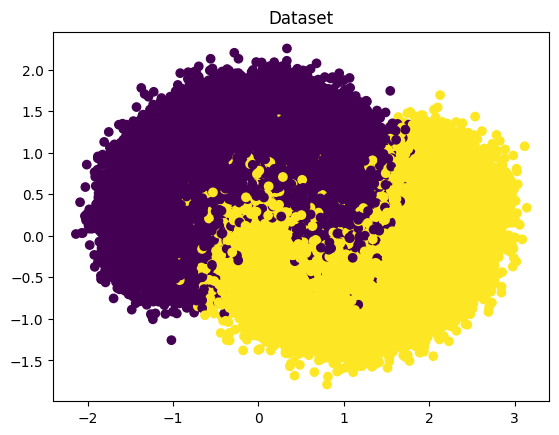

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_moons

from lightgbm import LGBMClassifier

X, y = make_moons(n_samples=500000, noise=0.3, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dataset")
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

lgb_clf = LGBMClassifier(
    n_estimators=10,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

lgb_clf.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 199900, number of negative: 200100
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003470 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 400000, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499750 -> initscore=-0.001000
[LightGBM] [Info] Start training from score -0.001000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.1
,n_estimators,10
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
y_pred = lgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

i:\Python Projects\machine learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.91217

Confusion Matrix:
 [[45666  4234]
 [ 4549 45551]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91     49900
           1       0.91      0.91      0.91     50100

    accuracy                           0.91    100000
   macro avg       0.91      0.91      0.91    100000
weighted avg       0.91      0.91      0.91    100000



i:\Python Projects\machine learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


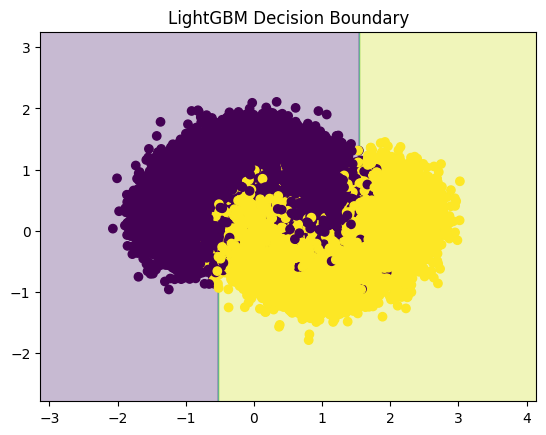

In [19]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = lgb_clf.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.title("LightGBM Decision Boundary")
plt.show()